 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
EPIDEMIA EN LA CIUDAD
Estado: Simulación exitosa

Infectados iniciales (t=0): 50 personas
Infectados finales (t=300): I = 6665.49 personas
Equilibrio simulado: 6665.49 personas   (Teórico: 6666.67)
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 


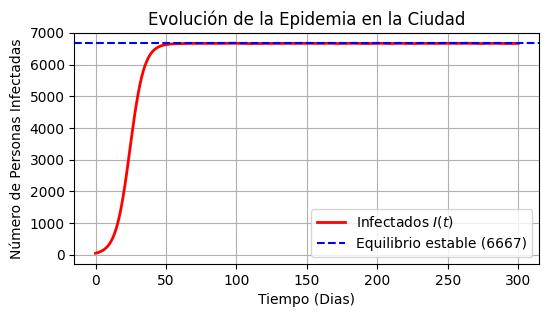

In [4]:
# EJERCICIO 3. EPIDEMIA EN UNA CIUDAD
# GINNETH SILVANA MARTÍNEZ URIBE

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

beta = 0.00003    # Tasa de contagio por día
gamma = 0.1       # Tasa de recuperación por día
N = 10000         # Población total constante


# Cambio de infectados: dI/dt = beta*(N - I)*I - gamma*I
# I = número de infectados, t = tiempo en días

def cambio_infectados(t, I):
  return beta * (N - I) * I - gamma * I


# Planteamiento del problema
I0 = [50]   # Condición inicial: 50 personas infectadas en t=0
lapso_tiempo = (0, 300) # Tiempo de simulación: de 0 a 300 días
dias_evaluacion = np.linspace(0, 300, 1000)


# Resolver
resultado = solve_ivp(
    cambio_infectados,
    lapso_tiempo,
    I0,
    t_eval=dias_evaluacion,
    method='RK45'
)


# Resultado
ultimo_dia = resultado.t[-1]
infectados_finales = resultado.y[0][-1]

print (" = " *45)
print ("EPIDEMIA EN LA CIUDAD")
print (f"Estado {'Simulación exitosa' if resultado.success else 'Fallo'}")
print ()
print (f"Infectados iniciales (t=0): {I0[0]} personas")
print (f"Infectados finales (t={int(ultimo_dia)}): I = {infectados_finales:.2f} personas")



# Verificación
equilibrio_teorico = N - (gamma/beta)
print (f"Equilibrio simulado: {infectados_finales:.2f} personas   (Teórico: {equilibrio_teorico:.2f})")
print (" = " *45)

# Gráfica
plt.figure(figsize=(6, 3))
plt.plot(resultado.t, resultado.y[0], label='Infectados $I(t)$', color='red', linewidth=2)
plt.axhline(y=equilibrio_teorico, color='blue', linestyle='--', label=f'Equilibrio estable ({equilibrio_teorico:.0f})')
plt.title('Evolución de la Epidemia en la Ciudad')
plt.xlabel('Tiempo (Dias)')
plt.ylabel('Número de Personas Infectadas')
plt.grid(True)
plt.legend()
plt.show()